In [1]:
%pip install --quiet -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from utils.hunt_data_loader import HuntDataLoader
import utils.analysis as analysis
import pandas as pd
from models.alzheiminator_3d import Generator3D
import torch
import os
from utils.loss_functions import ssim_3d

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Load Model

In [10]:
model_path = "out/mpgan_3d/3d_mpgan_G_4.3.pt"

model = Generator3D(in_channels=1, out_channels=1).to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

print("Model loaded from", model_path)

Model loaded from out/mpgan_3d/3d_mpgan_G_4.3.pt


# Create .csv of BPF

In [11]:
all_pairs = data_loader.get_all_pairs()

In [ ]:
rows = []
with torch.no_grad():
    for h3_path, h4_path in all_pairs:
        pid   = os.path.basename(os.path.dirname(h3_path))
        h3vol = data_loader.load_from_path(h3_path)                  # (D,H,W) np
        h4vol = data_loader.load_from_path(h4_path)                  # (D,H,W) np

        x = torch.from_numpy(h3vol).float()[None, None].to(device)
        out = model(x)
        y_pred = out[0] if isinstance(out, (tuple, list)) else out

        y_np = y_pred.detach().cpu().squeeze().clamp(0,1).numpy()

        ssim_value = ssim_3d(torch.from_numpy(h4vol).float()[None, None].to(device), y_pred)

        rows.append({"id": pid, "ssim": ssim_value.item()})

df = pd.DataFrame(rows)

# Save the DataFrame to a .csv file
df.to_csv("out/ssim/3d_mpgan_ssim_predictions.csv", index=False)
print("SSIM predictions saved to out/ssim/3d_mpgan_ssim_predictions.csv")
print("Average SSIM:", df["ssim"].mean())

# 4.2: Average SSIM: 0.87456
# 4.3: Average SSIM: 0.874787

SSIM predictions saved to out/ssim/3d_mpgan_ssim_predictions.csv
Average SSIM: 0.8747871925956324


/cluster/projects/vc/data/mic/closed/MRI_HUNT/images/images_3D_preprocessed/HUNT3/05881/05881_0_T1_PREP_MNI.nii.gz


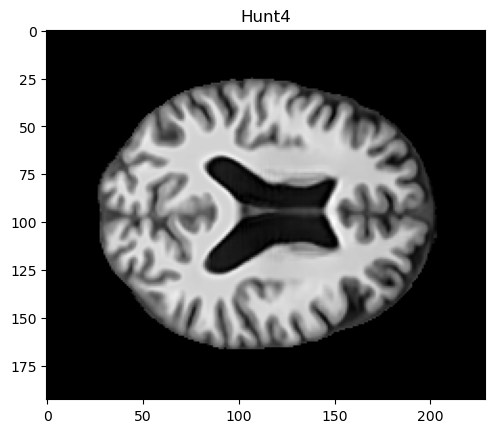

Predicted shape: (193, 229, 193)


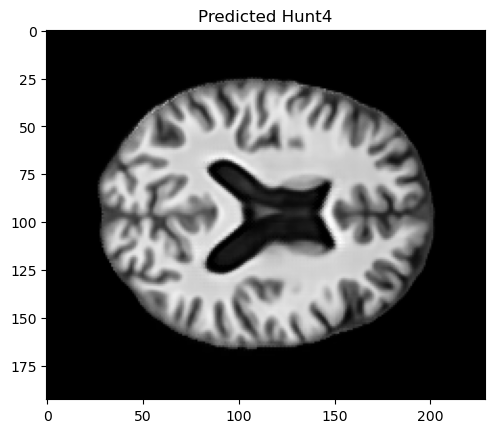

SSIM: 0.9076418876647949


In [9]:
print(all_pairs[0][0])

h4 = data_loader.load_from_path(all_pairs[0][0])
h4_middle_slice = data_loader.get_slice(all_pairs[0][1], 100)

plt.imshow(h4_middle_slice, cmap="gray")
plt.title("Hunt4")
plt.show()

with torch.no_grad():
    x = torch.from_numpy(h4).float()[None, None].to(device)
    out = model(x)
    y_pred = out[0] if isinstance(out, (tuple, list)) else out

    y_np = y_pred.detach().cpu().squeeze().clamp(0,1).numpy()
    #If a value is too small, set it to zero
    y_np[y_np < 1e-3] = 0
    print("Predicted shape:", y_np.shape)
    y_middle_slice = y_np[:,:,100]
    plt.imshow(y_middle_slice, cmap="gray")
    plt.title("Predicted Hunt4")
    plt.show()
    
    # Calculate SSIM
    ssim_value = ssim_3d(torch.from_numpy(h4).float()[None, None].to(device), y_pred)
    print("SSIM:", ssim_value.item())
